In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [35]:
df=pd.read_csv('/mnt/home/monkhayd/Simulations/Ejection_modeling/Mass_Fraction/Outputs/Ejection_Results/10733706_aggregated_results.txt')

In [36]:
df2=pd.read_csv('/mnt/home/monkhayd/Simulations/Ejection_modeling/Mass_Fraction/Outputs/Ejection_Results/10743964_aggregated_results.txt')

In [37]:
df.columns = ['Mass', 'semi_major_axis','ejected']
df2.columns = ['Mass', 'semi_major_axis','ejected']


In [38]:
df_agg=df2

In [39]:
df_agg

,Mass,semi_major_axis,ejected
0,0.0003,3.162278,1
1,0.0003,3.162278,1
2,0.0003,3.162278,1
3,0.0003,3.162278,1
4,0.0003,3.162278,1
...,...,...,...
54546,0.0003,3.162278,1
54547,0.0003,3.162278,1
54548,0.0003,3.162278,1
54549,0.0003,3.162278,1


In [40]:
df

,Mass,semi_major_axis,ejected
0,0.0003,3.162278,0
1,0.0003,3.162278,1
2,0.0003,3.162278,0
3,0.0003,3.162278,1
4,0.0003,3.162278,0
...,...,...,...
6455,0.0003,3.162278,1
6456,0.0003,3.162278,1
6457,0.0003,3.162278,0
6458,0.0003,3.162278,0


In [41]:
ejected_df=df_agg[df_agg.ejected == 0]

In [42]:
total_df=df_agg.groupby(['Mass', 'semi_major_axis']).size().reset_index(name='count')

In [43]:
total_df

,Mass,semi_major_axis,count
0,0.000300,3.162278,6149
1,0.000300,11.220185,6150
2,0.000300,39.810717,6000
3,0.001689,3.162278,6150
4,0.001689,11.220185,6000
5,0.001689,39.810717,6000
6,0.009495,3.162278,6106
7,0.009495,11.220185,6000
8,0.009495,39.810717,5996


In [44]:
heatmap_df=ejected_df.groupby(['Mass', 'semi_major_axis']).size().reset_index(name='count')

In [45]:
heatmap_df['ejection_fraction'] = heatmap_df['count'] / total_df['count']

In [46]:
heatmap_df

,Mass,semi_major_axis,count,ejection_fraction
0,0.000300,3.162278,1030,0.167507
1,0.000300,11.220185,1389,0.225854
2,0.000300,39.810717,1735,0.289167
3,0.001689,3.162278,3573,0.580976
4,0.001689,11.220185,3518,0.586333
5,0.001689,39.810717,3437,0.572833
6,0.009495,3.162278,3724,0.609892
7,0.009495,11.220185,3682,0.613667
8,0.009495,39.810717,3645,0.607905


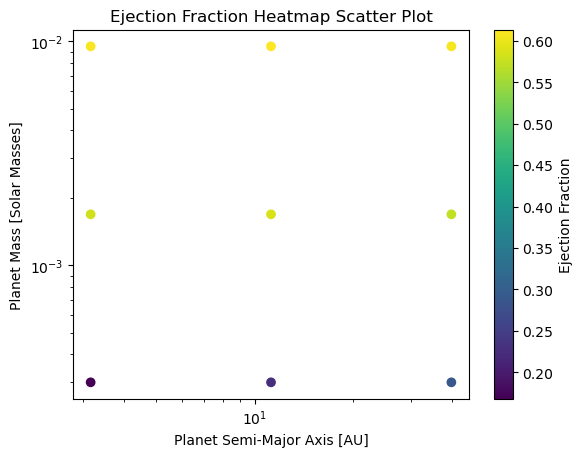

In [47]:
plt.scatter(heatmap_df['semi_major_axis'], heatmap_df['Mass'], c=heatmap_df['ejection_fraction'], cmap='viridis')
plt.xscale('log')
plt.yscale('log')
plt.colorbar(label='Ejection Fraction')
plt.xlabel('Planet Semi-Major Axis [AU]')
plt.ylabel('Planet Mass [Solar Masses]')
plt.title('Ejection Fraction Heatmap Scatter Plot')
plt.savefig('/mnt/home/monkhayd/Simulations/Ejection_modeling/Mass_Fraction/Outputs/Visualizations/ejection_fraction_heatmap_scatter.png', dpi=300)

In [48]:
tmax_old=1.5e6
T_old=5**(3/2)
n_Periods=tmax_old/T_old

In [49]:
n_Periods

134164.07864998738